<a href="https://colab.research.google.com/github/codewith-briankikuvi/AI-ML/blob/main/169925_policy_iteration_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Opening recorded data

In [2]:
policy_iteration_data = pd.read_csv("/content/policy_iteration.csv")

In [3]:
policy_iteration_data.head()

,"(0,0)","(1,0)","(2,0)","(3,0)","(4,0)","(5,0)","(6,0)","(7,0)","(8,0)","(9,0)",...,"(8,17)","(9,17)","(10,17)","(11,17)","(12,17)","(13,17)","(14,17)","(15,17)","(16,17)","(17,17)"
0,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000,0.000000,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,-0.040000,-0.040000,0,0,0,1.000000,-0.040000,-0.040000,-0.040000,0,...,-1.000000,-1.000000,-0.040000,-0.040000,-1.000000,1.000000,-0.040000,1.000000,-1.000000,0.0
2,0.023360,0.023360,0,0,0,1.063360,-0.174640,-0.174640,-0.079600,0,...,-1.894960,-1.134640,-0.174640,-0.839920,-0.406000,1.063360,0.744080,0.303040,-1.894960,0.0
3,0.167631,0.075893,0,0,0,0.893999,-0.363603,-0.223253,-0.118804,0,...,-2.103525,-1.343205,-0.910107,-0.527856,-0.238207,1.696897,0.275984,-0.468495,-2.705699,0.0
4,0.221657,0.120838,0,0,0,0.666716,-0.426556,-0.265791,-0.157616,0,...,-2.369620,-2.026606,-0.816027,-0.333175,0.296777,1.402159,-0.369148,-1.204758,-3.454226,0.0


In [4]:
policy_iteration_data.tail()

,"(0,0)","(1,0)","(2,0)","(3,0)","(4,0)","(5,0)","(6,0)","(7,0)","(8,0)","(9,0)",...,"(8,17)","(9,17)","(10,17)","(11,17)","(12,17)","(13,17)","(14,17)","(15,17)","(16,17)","(17,17)"
689,91.540535,91.386629,0,0,0,88.823578,87.686649,88.784365,89.929485,0,...,85.164799,87.486979,89.984957,91.487301,92.696367,95.132821,94.163629,94.226744,91.928152,0.0
690,91.543115,91.389209,0,0,0,88.826931,87.690140,88.787858,89.932979,0,...,85.167507,87.489686,89.987664,91.490008,92.699075,95.135528,94.166337,94.229452,91.930860,0.0
691,91.545669,91.391763,0,0,0,88.830245,87.693597,88.791317,89.936438,0,...,85.170187,87.492366,89.990344,91.492689,92.701755,95.138208,94.169017,94.232132,91.933540,0.0
692,91.548198,91.394291,0,0,0,88.833522,87.697020,88.794742,89.939862,0,...,85.172841,87.495020,89.992998,91.495342,92.704408,95.140862,94.171670,94.234785,91.936193,0.0
693,91.550701,91.396794,0,0,0,88.836763,87.700408,88.798132,89.943252,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Plotting relevant data

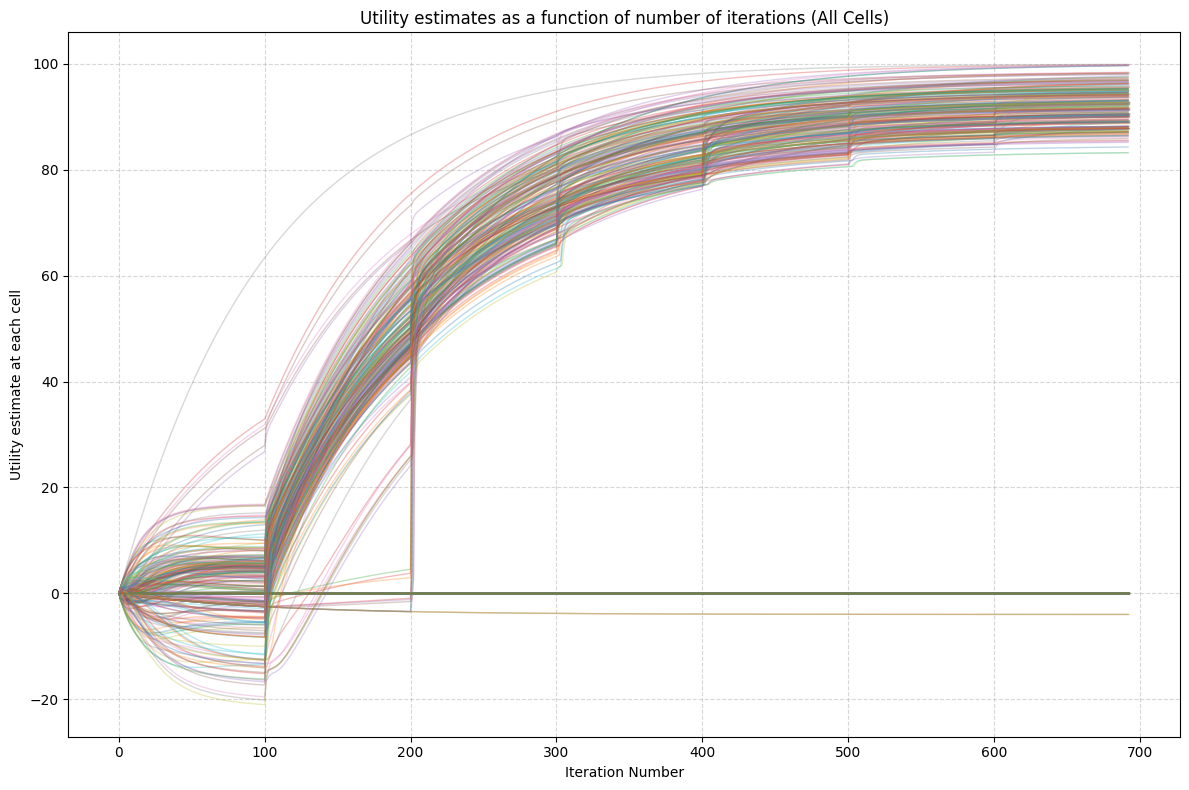

In [5]:
plt.figure(figsize=(12, 8))

# Passing the entire DataFrame plots all columns in a single vectorized step
plt.plot(policy_iteration_data, alpha=0.3, linewidth=1)


# Labels & styling
plt.title("Utility estimates as a function of number of iterations (All Cells)")
plt.xlabel("Iteration Number")
plt.ylabel("Utility estimate at each cell")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

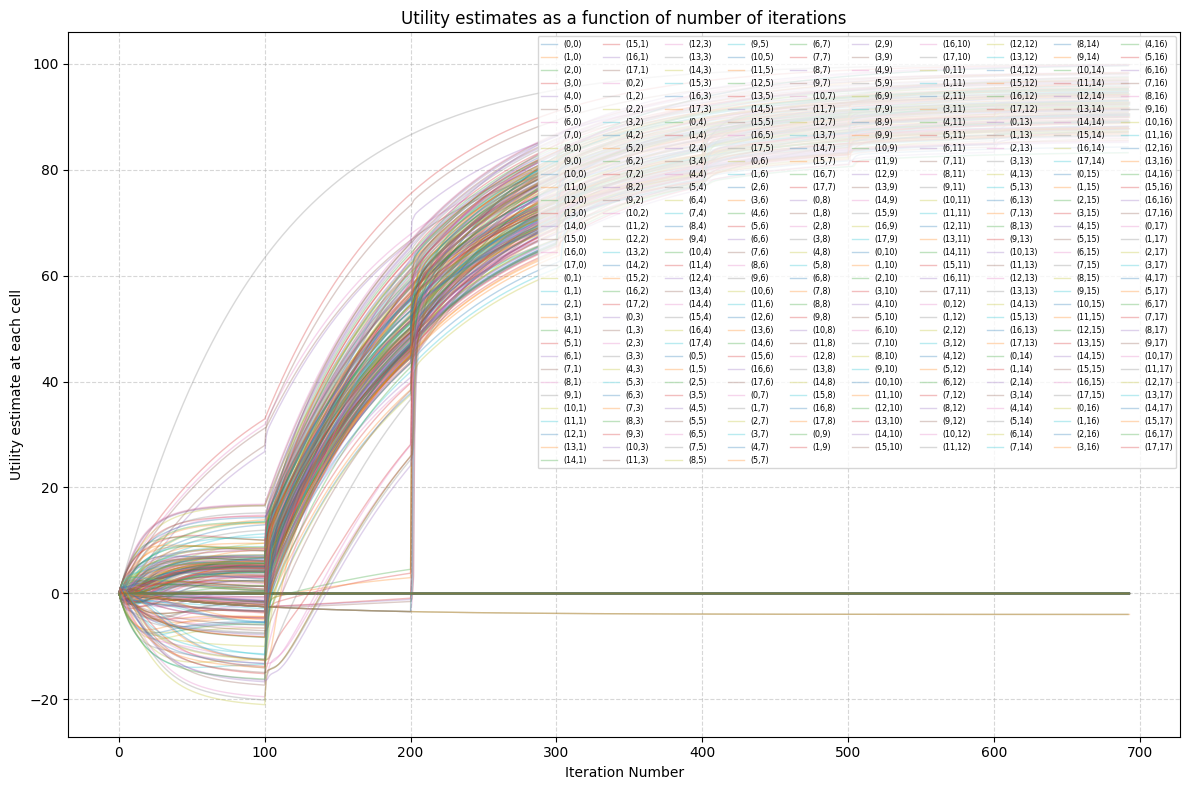

In [6]:
plt.figure(figsize=(12, 8))

for column in policy_iteration_data.columns:
  plt.plot(policy_iteration_data[column], label=column, alpha=0.3, linewidth=1)

plt.title("Utility estimates as a function of number of iterations")
plt.xlabel("Iteration Number")
plt.ylabel("Utility estimate at each cell")
plt.grid(True, linestyle="--", alpha=0.5)

# Full legend placed at the top right
plt.legend(loc="upper right", fontsize="xx-small", ncol=10)

plt.tight_layout()
plt.show()

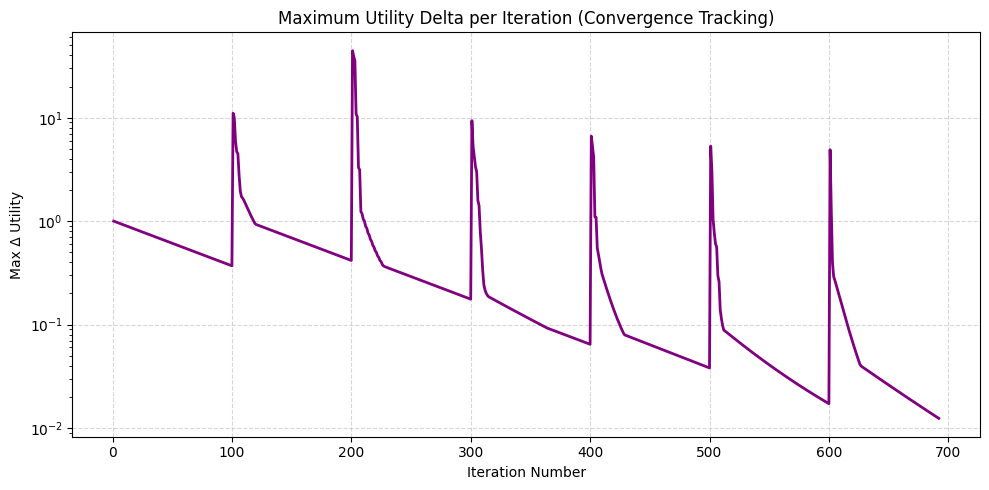

In [7]:
# Clean the data by dropping trailing NaNs (e.g., row 693) to isolate valid iterations
clean_data = policy_iteration_data.dropna()

# ---------------------------------------------------------
# Addition 1: Convergence Tracking (Max Delta per Iteration)
# ---------------------------------------------------------
# Calculate the absolute difference between consecutive iterations
# and find the maximum change across all 324 states for each step.
deltas = clean_data.diff().abs().max(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(deltas, color='purple', linewidth=2)
plt.title("Maximum Utility Delta per Iteration (Convergence Tracking)")
plt.xlabel("Iteration Number")
plt.ylabel("Max Δ Utility")
plt.yscale('log') # Log scale highlights the exponential decay to theta
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

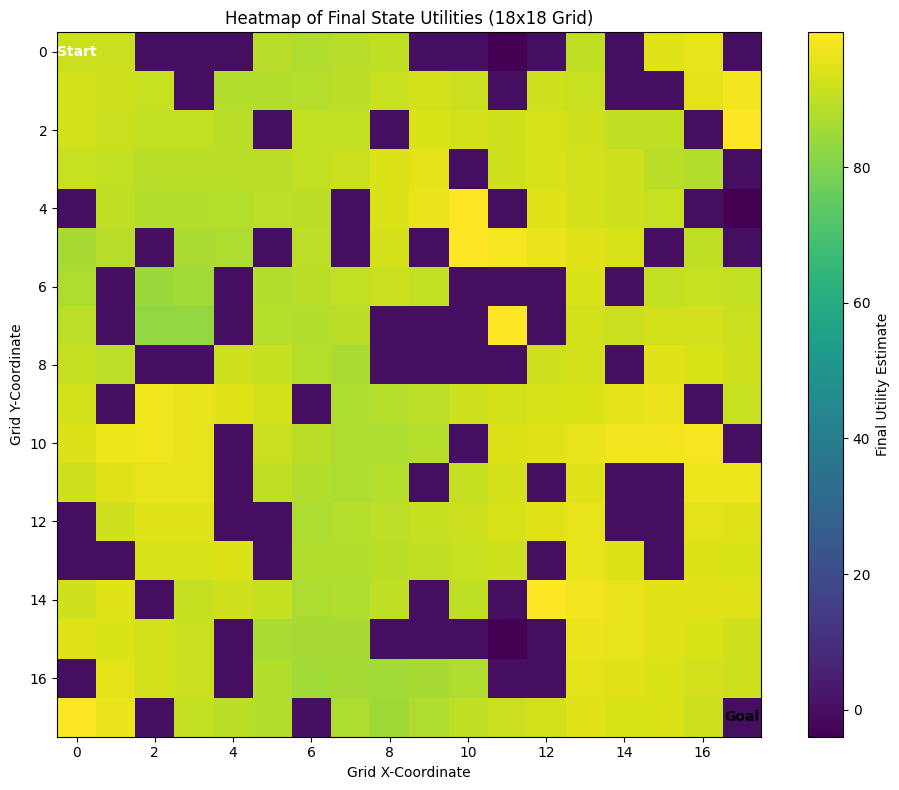

In [8]:
# ---------------------------------------------------------
# Addition 2: Spatial Heatmap of Final Utilities
# ---------------------------------------------------------
# Extract the final row of utility estimates and reshape it
# into the original 18x18 environment grid.
final_utilities = clean_data.iloc[-1].values.reshape(18, 18)

plt.figure(figsize=(10, 8))
# Using 'viridis' colormap: yellow indicates goals, dark purple indicates penalties
heatmap = plt.imshow(final_utilities, cmap='viridis', interpolation='nearest')
plt.colorbar(heatmap, label='Final Utility Estimate')
plt.title("Heatmap of Final State Utilities (18x18 Grid)")
plt.xlabel("Grid X-Coordinate")
plt.ylabel("Grid Y-Coordinate")

# Optional: Annotate the start and extreme states
plt.text(0, 0, 'Start', color='white', ha='center', va='center', fontweight='bold')
plt.text(17, 17, 'Goal', color='black', ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()